# RQ2 v2 Analysis — Does Static Typing Reduce Maintenance Burden for AI-Generated Code?

**Research Question 2**: *Does static typing reduce maintenance burden for AI-generated code relative to dynamically typed languages?*

**Core Hypothesis**: The maintenance burden gap between AI-generated and human-generated pull requests is smaller in statically typed languages than in dynamically typed languages.

**Data source**: `rq1_main_frame_v2.parquet` — 18,942 PRs with SZZ-traced defect labels (261 defective at 90 days)

### Language Type Groups
| Group | Label | Languages |
|-------|-------|-----------|
| 0 | **Static** | TypeScript, C#, Rust, Go, Java, C++, C, Swift |
| 1 | **Dynamic** | Python, Ruby, JavaScript, PHP |
| 2 | Other | Zig, HTML, Nim, Dart, Elixir, … (excluded) |

### Sections
1. Data Loading & Overview
2. Descriptive Statistics — Defect Rates by Typing × AI
3. Visualization — Grouped Bar Charts
4. Per-Language Breakdown
5. Fisher's Exact Tests (Static / Dynamic separately)
6. Logistic Regression with Interaction (ai_pr × is_static)
7. Negative Binomial Regression with Interaction
8. Odds Ratios & Rate Ratios
9. Marginal Effects — AI effect within each language type
10. Coefficient Forest Plot
11. Robustness — Observable-Only Sensitivity
12. Robustness — Stratified Models (Static-Only vs Dynamic-Only)
13. Power Analysis for Interaction Term

## 1. Data Loading & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.power import NormalIndPower

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

LANG_LABELS = {0: "Static", 1: "Dynamic"}
AI_LABELS   = {0: "Human", 1: "AI"}

# ── Load the updated v2 mainframe ──
df_full = pd.read_parquet("../results/rq1_main_frame_v2.parquet")
print(f"Full dataset: {len(df_full):,} PRs × {df_full.shape[1]} columns across {df_full['repo_full_name'].nunique():,} repos")
print(f"Language type distribution:")
for g in sorted(df_full["language_type_group"].unique()):
    label = LANG_LABELS.get(g, "Other")
    n = (df_full["language_type_group"] == g).sum()
    print(f"  {g} ({label}): {n:,} PRs")

# ── Filter to Static (0) and Dynamic (1) only ──
df = df_full[df_full["language_type_group"].isin([0, 1])].copy()
df["is_static"] = (df["language_type_group"] == 0).astype(int)
df["lang_label"] = df["language_type_group"].map(LANG_LABELS)
df["author"]     = df["ai_pr"].map(AI_LABELS)

# Log transforms
df["log_pr_size"] = np.log(df["pr_size_loc"].clip(lower=1))
df["log_stars"]   = np.log(df["repo_stars"] + 1)

print(f"\nRQ2 subset (Static + Dynamic): {len(df):,} PRs across {df['repo_full_name'].nunique():,} repos")
print(f"  Static:  {(df['is_static']==1).sum():,}")
print(f"  Dynamic: {(df['is_static']==0).sum():,}")
print(f"  Defective (90d): {df['has_defect_90d'].sum()}")
print(f"  AI PRs: {(df['ai_pr']==1).sum():,}  |  Human PRs: {(df['ai_pr']==0).sum():,}")

Full dataset: 18,942 PRs × 57 columns across 1,479 repos
Language type distribution:
  0 (Static): 12,497 PRs
  1 (Dynamic): 5,082 PRs
  2 (Other): 1,363 PRs

RQ2 subset (Static + Dynamic): 17,579 PRs across 1,329 repos
  Static:  12,497
  Dynamic: 5,082
  Defective (90d): 247
  AI PRs: 11,469  |  Human PRs: 6,110


## 2. Descriptive Statistics — Defect Rates by Typing × AI Status

Cross-tabulation of 90-day, 60-day, and 30-day defect rates broken down by language type system and PR author (Human vs AI). Rates expressed in **basis points** (per 10,000 PRs) for readability.

In [2]:
# ── Multi-window defect rates by language type × author ──
rows = []
for w in [30, 60, 90]:
    col = f"has_defect_{w}d"
    for lang in [0, 1]:
        for ai in [0, 1]:
            mask = (df["language_type_group"] == lang) & (df["ai_pr"] == ai)
            sub = df[mask]
            n = len(sub)
            d = int(sub[col].sum())
            rate = d / n if n else 0
            rows.append({
                "window": f"{w}d",
                "lang_type": LANG_LABELS[lang],
                "author": AI_LABELS[ai],
                "n": n,
                "defects": d,
                "rate_bps": rate * 10_000,
            })

desc = pd.DataFrame(rows)
print("─── Defect rates by Window × Language Type × Author (basis points) ───\n")
print(desc.to_string(index=False))

# ── Raw AI advantage (Human rate - AI rate) in each language type ──
print("\n─── AI advantage (Human − AI defect rate) ───\n")
for w in [30, 60, 90]:
    col = f"has_defect_{w}d"
    for lang_label in ["Static", "Dynamic"]:
        h_rate = desc[(desc["window"]==f"{w}d") & (desc["lang_type"]==lang_label) & (desc["author"]=="Human")]["rate_bps"].values[0]
        a_rate = desc[(desc["window"]==f"{w}d") & (desc["lang_type"]==lang_label) & (desc["author"]=="AI")]["rate_bps"].values[0]
        diff = h_rate - a_rate
        print(f"  {w}d {lang_label:8s}: Human {h_rate:.1f} bp − AI {a_rate:.1f} bp = Δ {diff:+.1f} bp {'(Human higher)' if diff > 0 else '(AI higher)'}")

# ── 2×2 contingency summary for 90d ──
print("\n─── 90d Defect Rate Cross-Tab ───\n")
ct = df.groupby(["lang_label", "author"])["has_defect_90d"].agg(["count", "sum", "mean"])
ct.columns = ["n", "defects", "rate"]
ct["rate_bps"] = ct["rate"] * 10_000
print(ct.to_string())

─── Defect rates by Window × Language Type × Author (basis points) ───

window lang_type author    n  defects   rate_bps
   30d    Static  Human 4170       46 110.311751
   30d    Static     AI 8327      105 126.095833
   30d   Dynamic  Human 1940       30 154.639175
   30d   Dynamic     AI 3142       18  57.288351
   60d    Static  Human 4170       65 155.875300
   60d    Static     AI 8327      107 128.497658
   60d   Dynamic  Human 1940       40 206.185567
   60d   Dynamic     AI 3142       20  63.653724
   90d    Static  Human 4170       75 179.856115
   90d    Static     AI 8327      107 128.497658
   90d   Dynamic  Human 1940       45 231.958763
   90d   Dynamic     AI 3142       20  63.653724

─── AI advantage (Human − AI defect rate) ───

  30d Static  : Human 110.3 bp − AI 126.1 bp = Δ -15.8 bp (AI higher)
  30d Dynamic : Human 154.6 bp − AI 57.3 bp = Δ +97.4 bp (Human higher)
  60d Static  : Human 155.9 bp − AI 128.5 bp = Δ +27.4 bp (Human higher)
  60d Dynamic : Human 206.2 

## 3. Visualization — Defect Rates by Language Type × Author

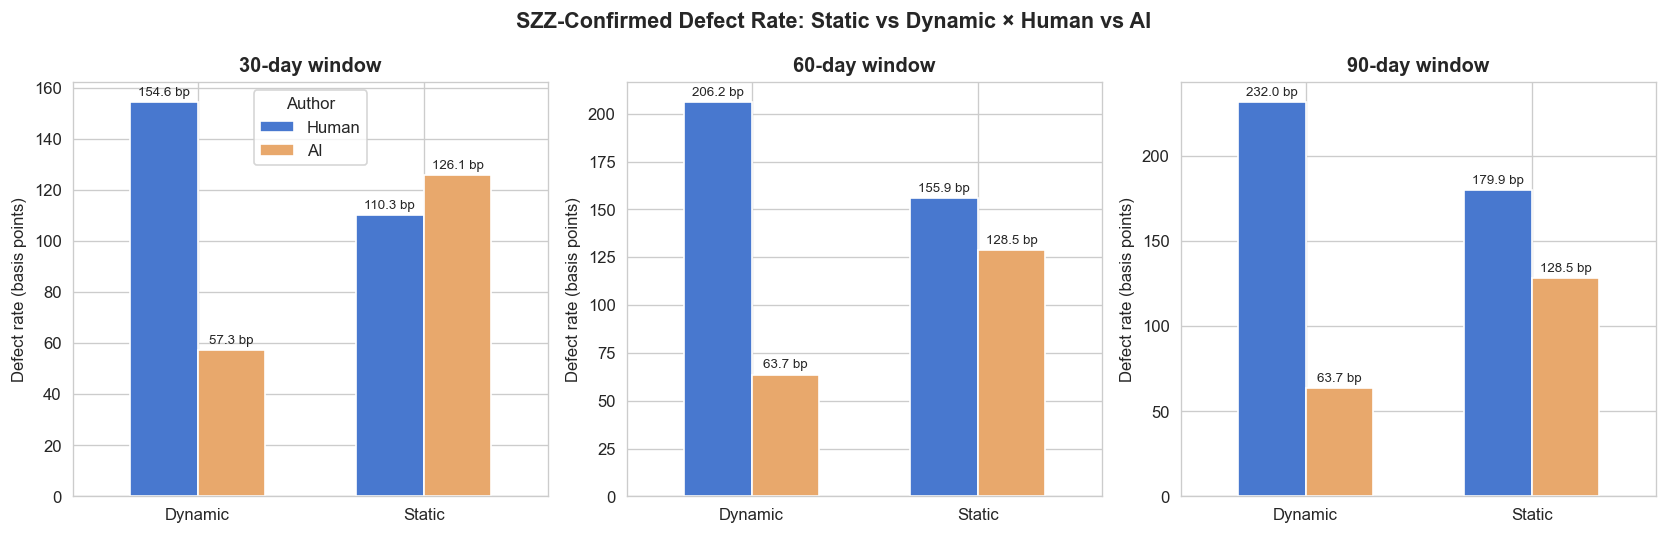

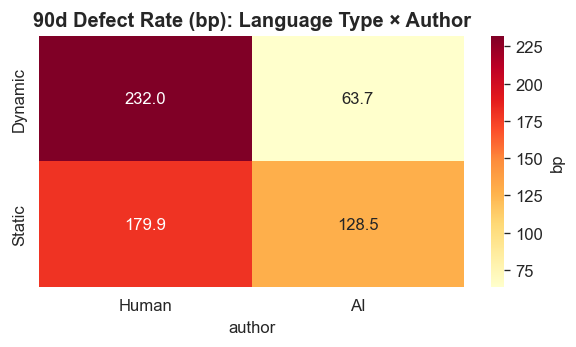

In [3]:
# ── Grouped bar chart: 90d defect rate by Language Type × Author ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)
colors = ["#4878CF", "#E8A86C"]

for i, w in enumerate([30, 60, 90]):
    ax = axes[i]
    sub = desc[desc["window"] == f"{w}d"]
    pivot = sub.pivot(index="lang_type", columns="author", values="rate_bps")
    pivot = pivot[["Human", "AI"]]  # order
    pivot.plot(kind="bar", ax=ax, color=colors, edgecolor="white", width=0.6)
    ax.set_title(f"{w}-day window", fontweight="bold")
    ax.set_ylabel("Defect rate (basis points)")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f bp", fontsize=8, padding=2)
    if i > 0:
        ax.get_legend().remove()
    else:
        ax.legend(title="Author")

fig.suptitle("SZZ-Confirmed Defect Rate: Static vs Dynamic × Human vs AI", fontweight="bold", fontsize=13)
fig.tight_layout()
plt.show()

# ── Heatmap: defect rate by language type × author (90d) ──
pivot_heat = desc[desc["window"]=="90d"].pivot(index="lang_type", columns="author", values="rate_bps")
pivot_heat = pivot_heat[["Human", "AI"]]

fig, ax = plt.subplots(figsize=(5, 3))
sns.heatmap(pivot_heat, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "bp"})
ax.set_title("90d Defect Rate (bp): Language Type × Author", fontweight="bold")
ax.set_ylabel("")
fig.tight_layout()
plt.show()

## 4. Per-Language Breakdown

Defect rates for individual programming languages (minimum 100 PRs), to check that the static/dynamic grouping doesn't mask important language-level variation.

─── 90d Defect Rate by Language × Author (bp) ───

author                    Human    AI  n_total
repo_language lang_label                      
TypeScript    Static      249.2  92.9     6716
Python        Dynamic     271.0  75.6     3652
C#            Static      144.7 367.3     1996
Rust          Static       68.3  65.7     1200
Go            Static      115.9  28.7     1042
Java          Static        0.0  34.9      742
Ruby          Dynamic     189.4  51.0      656
JavaScript    Dynamic      87.0  23.6      653
C++           Static        0.0 113.6      388
C             Static        0.0 111.7      269
PHP           Dynamic       0.0   0.0      112


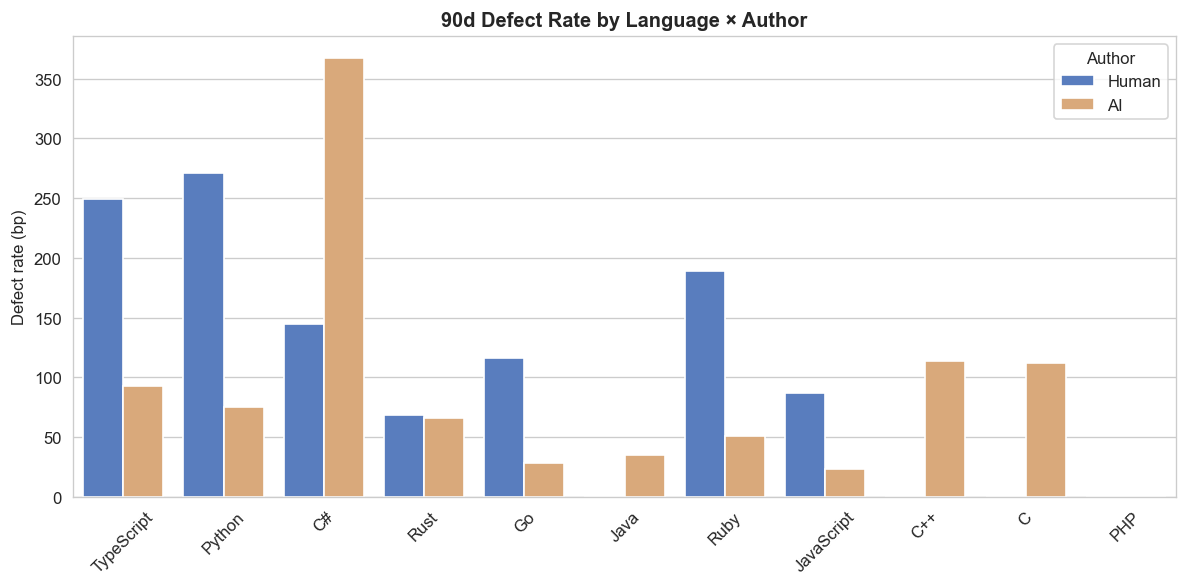

In [4]:
# ── Per-language defect rates (languages with >= 100 PRs) ──
lang_stats = df.groupby(["repo_language", "lang_label", "author"]).agg(
    n=("has_defect_90d", "count"),
    defects=("has_defect_90d", "sum"),
).reset_index()
lang_stats["rate_bps"] = (lang_stats["defects"] / lang_stats["n"]) * 10_000

# Filter to languages with at least 100 total PRs
lang_totals = lang_stats.groupby("repo_language")["n"].sum()
keep_langs = lang_totals[lang_totals >= 100].index
lang_stats = lang_stats[lang_stats["repo_language"].isin(keep_langs)]

print("─── 90d Defect Rate by Language × Author (bp) ───\n")
pivot = lang_stats.pivot_table(index=["repo_language", "lang_label"], columns="author", values="rate_bps", aggfunc="first")
pivot["n_total"] = lang_stats.groupby("repo_language")["n"].sum().values[:len(pivot)]
pivot = pivot.sort_values("n_total", ascending=False)
print(pivot[["Human", "AI", "n_total"]].to_string(float_format=lambda x: f"{x:.1f}"))

# ── Chart ──
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = lang_stats.copy()
plot_data["lang_order"] = plot_data["repo_language"].map(
    {lang: i for i, lang in enumerate(pivot.index.get_level_values(0))}
)
plot_data = plot_data.sort_values("lang_order")

sns.barplot(data=plot_data, x="repo_language", y="rate_bps", hue="author",
            hue_order=["Human", "AI"], palette=colors, ax=ax, edgecolor="white")
ax.set_title("90d Defect Rate by Language × Author", fontweight="bold")
ax.set_ylabel("Defect rate (bp)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Author")
fig.tight_layout()
plt.show()

## 5. Fisher's Exact Tests — AI vs Human within Each Language Type

Test whether AI PRs have a different defect rate than Human PRs **separately** within Static and Dynamic languages. Then test whether the AI advantage differs between Static and Dynamic via a Breslow-Day–style comparison.

In [5]:
# ── Fisher's exact: AI vs Human within Static and Dynamic ──
print("═══ Fisher's Exact Tests: AI vs Human within Each Language Type (90d) ═══\n")

fisher_results = {}
for lang_code, lang_name in LANG_LABELS.items():
    sub = df[df["language_type_group"] == lang_code]
    ct = pd.crosstab(sub["ai_pr"], sub["has_defect_90d"])
    print(f"── {lang_name} Languages ──")
    print(ct.rename(index=AI_LABELS, columns={0: "No defect", 1: "Defect"}))

    table = ct.values
    odds_ratio, p_val = stats.fisher_exact(table, alternative="two-sided")
    fisher_results[lang_name] = {"OR": odds_ratio, "p": p_val}

    h_rate = sub[sub["ai_pr"]==0]["has_defect_90d"].mean() * 10_000
    a_rate = sub[sub["ai_pr"]==1]["has_defect_90d"].mean() * 10_000
    sig = "significant" if p_val < 0.05 else "NOT significant"
    print(f"  Fisher exact: OR = {odds_ratio:.3f}, p = {p_val:.4f}")
    print(f"  Human {h_rate:.1f} bp vs AI {a_rate:.1f} bp — {sig} at α=0.05")
    print()

# ── Test whether AI effect differs across language types (interaction proxy) ──
# Cochran-Mantel-Haenszel or simple comparison of ORs
print("── Comparison of AI Effect Across Language Types ──")
or_static  = fisher_results["Static"]["OR"]
or_dynamic = fisher_results["Dynamic"]["OR"]
print(f"  AI OR in Static:  {or_static:.3f}")
print(f"  AI OR in Dynamic: {or_dynamic:.3f}")
print(f"  Ratio of ORs (Static/Dynamic): {or_static/or_dynamic:.3f}")
print(f"  → {'Similar' if 0.5 < or_static/or_dynamic < 2.0 else 'Different'} AI effect across type systems")
print(f"  (Formal interaction test via regression below)")

═══ Fisher's Exact Tests: AI vs Human within Each Language Type (90d) ═══

── Static Languages ──
has_defect_90d  No defect  Defect
ai_pr                            
Human                4095      75
AI                   8220     107
  Fisher exact: OR = 0.711, p = 0.0265
  Human 179.9 bp vs AI 128.5 bp — significant at α=0.05

── Dynamic Languages ──
has_defect_90d  No defect  Defect
ai_pr                            
Human                1895      45
AI                   3122      20
  Fisher exact: OR = 0.270, p = 0.0000
  Human 232.0 bp vs AI 63.7 bp — significant at α=0.05

── Comparison of AI Effect Across Language Types ──
  AI OR in Static:  0.711
  AI OR in Dynamic: 0.270
  Ratio of ORs (Static/Dynamic): 2.635
  → Different AI effect across type systems
  (Formal interaction test via regression below)


## 6. Logistic Regression with Interaction Term

Model: `has_defect_90d ~ ai_pr × is_static + log_pr_size + repo_age_years + log_stars + contributor_count + C(task_type_group)`

Cluster-robust standard errors grouped by `repo_full_name`.

The key coefficient is **`ai_pr:is_static`** — if significant, it means the AI effect on defect probability differs between static and dynamic languages.

In [6]:
# ── Prepare modelling frame ──
needed = [
    "has_defect_90d", "defect_count_90d", "ai_pr", "is_static",
    "log_pr_size", "repo_age_years", "log_stars", "contributor_count",
    "task_type_group", "repo_full_name", "szz_observable",
    "has_defect_60d", "has_defect_30d", "defect_count_60d", "defect_count_30d",
    "lang_label", "author", "language_type_group", "repo_language",
    "domain_type_group",
]
dfm = df[[c for c in needed if c in df.columns]].dropna(subset=[
    "has_defect_90d", "ai_pr", "is_static", "log_pr_size",
    "repo_age_years", "log_stars", "contributor_count", "task_type_group"
]).copy()
groups = dfm["repo_full_name"].to_numpy()

n_events = int(dfm["has_defect_90d"].sum())
n_vars = 8  # approximate number of model parameters
print(f"Modelling frame: {len(dfm):,} rows, {n_events} defect events")
print(f"Events-per-variable (EPV): {n_events/n_vars:.1f}  (rule of thumb ≥ 10)")

# ── Logistic regression with interaction ──
formula = ("has_defect_90d ~ ai_pr * is_static + log_pr_size + repo_age_years "
           "+ log_stars + contributor_count + C(task_type_group)")

logit_model = smf.logit(formula, data=dfm).fit(
    disp=0, cov_type="cluster", cov_kwds={"groups": groups}
)

print("\n═══ Logistic Regression: has_defect_90d ~ ai_pr × is_static + controls ═══\n")
print(logit_model.summary())

# ── Highlight interaction term ──
interaction_coef = logit_model.params.get("ai_pr:is_static", float("nan"))
interaction_p    = logit_model.pvalues.get("ai_pr:is_static", float("nan"))
interaction_or   = np.exp(interaction_coef)
print(f"\n★ Interaction term (ai_pr × is_static):")
print(f"  Coefficient: {interaction_coef:.4f}")
print(f"  OR: {interaction_or:.3f}")
print(f"  p-value: {interaction_p:.4f}")
print(f"  → {'Significant' if interaction_p < 0.05 else 'NOT significant'} at α=0.05")
print(f"  Interpretation: The AI effect on defect odds {'DOES' if interaction_p < 0.05 else 'does NOT'} "
      f"significantly differ between static and dynamic languages.")

Modelling frame: 14,878 rows, 220 defect events
Events-per-variable (EPV): 27.5  (rule of thumb ≥ 10)

═══ Logistic Regression: has_defect_90d ~ ai_pr × is_static + controls ═══

                           Logit Regression Results                           
Dep. Variable:         has_defect_90d   No. Observations:                14878
Model:                          Logit   Df Residuals:                    14866
Method:                           MLE   Df Model:                           11
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                 0.09714
Time:                        15:55:54   Log-Likelihood:                -1034.2
converged:                       True   LL-Null:                       -1145.4
Covariance Type:              cluster   LLR p-value:                 1.521e-41
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
I

In [16]:
import matplotlib.pyplot as plt

# statsmodels coefficient table
tbl = logit_model.summary2().tables[1].reset_index()
tbl = tbl.rename(columns={"index": "term"}).round(4)

fig_h = 0.45 * len(tbl) + 1.2
fig, ax = plt.subplots(figsize=(12, fig_h))
ax.axis("off")

table = ax.table(
    cellText=tbl.astype(str).values,
    colLabels=tbl.columns,
    cellLoc="center",
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.2)

fig.tight_layout()
fig.savefig("logit_model_table.png", dpi=300, bbox_inches="tight")
plt.close(fig)


## 7. Negative Binomial Regression with Interaction Term

Count model for `defect_count_90d` with the same interaction specification. Negative Binomial handles overdispersion in the defect count data.

In [7]:
# ── Negative Binomial regression with interaction ──
nb_formula = ("defect_count_90d ~ ai_pr * is_static + log_pr_size + repo_age_years "
              "+ log_stars + contributor_count + C(task_type_group)")

nb_model = smf.glm(
    nb_formula, data=dfm, family=sm.families.NegativeBinomial()
).fit(cov_type="cluster", cov_kwds={"groups": groups})

print("═══ Negative Binomial Regression: defect_count_90d ~ ai_pr × is_static + controls ═══\n")
print(nb_model.summary())

# ── Highlight interaction ──
nb_int_coef = nb_model.params.get("ai_pr:is_static", float("nan"))
nb_int_p    = nb_model.pvalues.get("ai_pr:is_static", float("nan"))
nb_int_irr  = np.exp(nb_int_coef)

ai_coef = nb_model.params.get("ai_pr", float("nan"))
ai_irr  = np.exp(ai_coef)

print(f"\n★ ai_pr main effect: IRR = {ai_irr:.3f} (coef = {ai_coef:.4f})")
print(f"★ Interaction (ai_pr × is_static): IRR = {nb_int_irr:.3f}, p = {nb_int_p:.4f}")
print(f"  → {'Significant' if nb_int_p < 0.05 else 'NOT significant'} at α=0.05")

/Users/stevotrujillo/Desktop/CS260-MBILLMC/.venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


═══ Negative Binomial Regression: defect_count_90d ~ ai_pr × is_static + controls ═══

                 Generalized Linear Model Regression Results                  
Dep. Variable:       defect_count_90d   No. Observations:                14878
Model:                            GLM   Df Residuals:                    14866
Model Family:        NegativeBinomial   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1444.1
Date:                Thu, 12 Mar 2026   Deviance:                       2175.4
Time:                        15:56:42   Pearson chi2:                 4.05e+04
No. Iterations:                     8   Pseudo R-squ. (CS):            0.02699
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------

## 8. Odds Ratios & Rate Ratios with 95% Confidence Intervals

Exponentiated coefficients for interpretability. Focus on `ai_pr`, `is_static`, and the interaction `ai_pr:is_static`.

In [8]:
# ── Odds Ratios from Logistic Regression ──
key_terms = ["ai_pr", "is_static", "ai_pr:is_static"]

print("═══ Logistic Regression — Odds Ratios (95% CI) ═══\n")
logit_ci = logit_model.conf_int()
logit_or = pd.DataFrame({
    "OR": np.exp(logit_model.params),
    "CI_lower": np.exp(logit_ci[0]),
    "CI_upper": np.exp(logit_ci[1]),
    "p-value": logit_model.pvalues,
})
print(logit_or.loc[[t for t in key_terms if t in logit_or.index]].to_string(float_format=lambda x: f"{x:.4f}"))

# ── Rate Ratios from NB Regression ──
print("\n═══ Negative Binomial — Incidence Rate Ratios (95% CI) ═══\n")
nb_ci = nb_model.conf_int()
nb_irr = pd.DataFrame({
    "IRR": np.exp(nb_model.params),
    "CI_lower": np.exp(nb_ci[0]),
    "CI_upper": np.exp(nb_ci[1]),
    "p-value": nb_model.pvalues,
})
print(nb_irr.loc[[t for t in key_terms if t in nb_irr.index]].to_string(float_format=lambda x: f"{x:.4f}"))

# ── Combined summary ──
print("\n─── Combined Key Estimates ───\n")
summary_data = []
for term in key_terms:
    if term in logit_or.index:
        row = logit_or.loc[term]
        summary_data.append({
            "Term": term, "Model": "Logistic",
            "Estimate": f"{row['OR']:.3f}", "95% CI": f"[{row['CI_lower']:.3f}, {row['CI_upper']:.3f}]",
            "p": f"{row['p-value']:.4f}"
        })
    if term in nb_irr.index:
        row = nb_irr.loc[term]
        summary_data.append({
            "Term": term, "Model": "Neg. Binomial",
            "Estimate": f"{row['IRR']:.3f}", "95% CI": f"[{row['CI_lower']:.3f}, {row['CI_upper']:.3f}]",
            "p": f"{row['p-value']:.4f}"
        })
print(pd.DataFrame(summary_data).to_string(index=False))

═══ Logistic Regression — Odds Ratios (95% CI) ═══

                    OR  CI_lower  CI_upper  p-value
ai_pr           0.2006    0.0723    0.5565   0.0020
is_static       0.5450    0.1267    2.3446   0.4148
ai_pr:is_static 2.7977    0.6942   11.2751   0.1480

═══ Negative Binomial — Incidence Rate Ratios (95% CI) ═══

                   IRR  CI_lower  CI_upper  p-value
ai_pr           0.1647    0.0565    0.4806   0.0010
is_static       0.5807    0.1211    2.7840   0.4967
ai_pr:is_static 2.5773    0.5664   11.7272   0.2207

─── Combined Key Estimates ───

           Term         Model Estimate          95% CI      p
          ai_pr      Logistic    0.201  [0.072, 0.557] 0.0020
          ai_pr Neg. Binomial    0.165  [0.056, 0.481] 0.0010
      is_static      Logistic    0.545  [0.127, 2.345] 0.4148
      is_static Neg. Binomial    0.581  [0.121, 2.784] 0.4967
ai_pr:is_static      Logistic    2.798 [0.694, 11.275] 0.1480
ai_pr:is_static Neg. Binomial    2.577 [0.566, 11.727] 0.2207


## 9. Marginal Effects — AI Effect within Each Language Type

Compute the predicted probability difference (AI=1 vs AI=0) separately within Static and Dynamic subsets, holding all other covariates at observed values (average marginal effect).

In [9]:
# ── Average marginal effect of AI, computed within each language type ──
print("═══ Average Marginal Effects of AI on P(defect) ═══\n")

for lang_code, lang_name in [(1, "Static"), (0, "Dynamic")]:
    sub = dfm[dfm["is_static"] == lang_code].copy()

    # Predict with ai_pr = 1
    sub_ai = sub.copy(); sub_ai["ai_pr"] = 1
    p_ai = logit_model.predict(sub_ai)

    # Predict with ai_pr = 0
    sub_human = sub.copy(); sub_human["ai_pr"] = 0
    p_human = logit_model.predict(sub_human)

    # Average marginal effect
    ame = (p_ai - p_human).mean()
    ame_bps = ame * 10_000

    # Bootstrap CI (1000 reps)
    rng = np.random.default_rng(42)
    boot_ames = []
    for _ in range(1000):
        idx = rng.choice(len(sub), size=len(sub), replace=True)
        sub_b = sub.iloc[idx]
        sub_b_ai = sub_b.copy(); sub_b_ai["ai_pr"] = 1
        sub_b_h  = sub_b.copy(); sub_b_h["ai_pr"] = 0
        boot_ames.append((logit_model.predict(sub_b_ai) - logit_model.predict(sub_b_h)).mean())
    ci_lo, ci_hi = np.percentile(boot_ames, [2.5, 97.5])

    print(f"  {lang_name:8s}: AME = {ame_bps:+.2f} bp  95% CI [{ci_lo*10_000:+.2f}, {ci_hi*10_000:+.2f}] bp")
    print(f"           (AI {'decreases' if ame < 0 else 'increases'} P(defect) by ~{abs(ame_bps):.1f} bp)")

print(f"\n  Difference in AME (Static − Dynamic) tests whether the interaction is practically meaningful.")

═══ Average Marginal Effects of AI on P(defect) ═══

  Static  : AME = -96.02 bp  95% CI [-97.65, -94.26] bp
           (AI decreases P(defect) by ~96.0 bp)
  Dynamic : AME = -247.61 bp  95% CI [-255.00, -240.55] bp
           (AI decreases P(defect) by ~247.6 bp)

  Difference in AME (Static − Dynamic) tests whether the interaction is practically meaningful.


## 10. Coefficient Forest Plot

Visual comparison of key coefficients (and their 95% CIs) from both the Logistic and NB models.

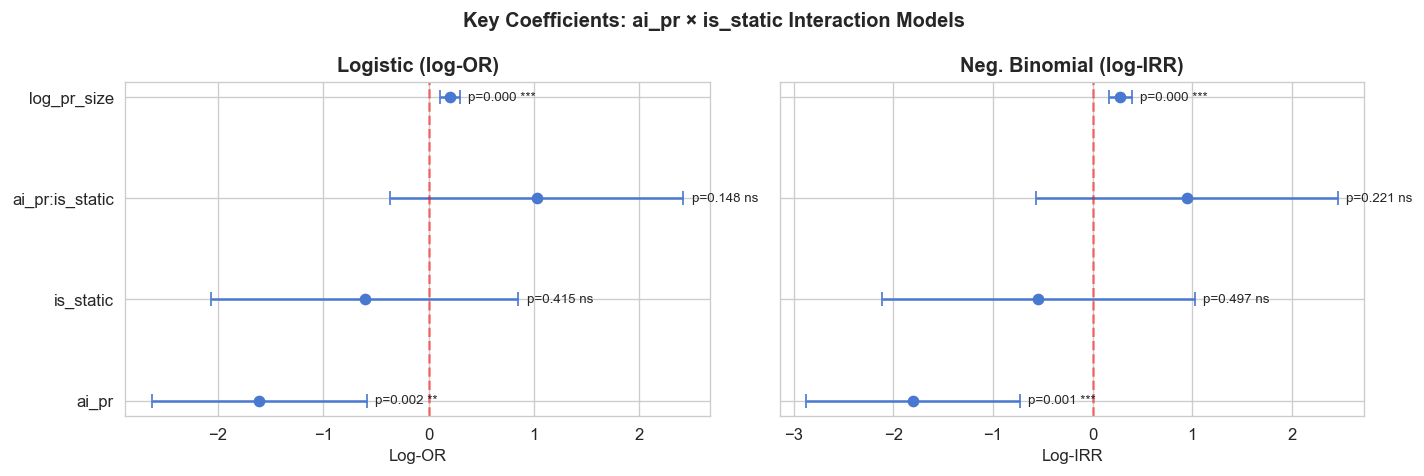

In [10]:
# ── Forest plot of key coefficients ──
focus_terms = ["ai_pr", "is_static", "ai_pr:is_static", "log_pr_size"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (model, model_name, metric) in zip(axes, [
    (logit_model, "Logistic (log-OR)", "Log-OR"),
    (nb_model, "Neg. Binomial (log-IRR)", "Log-IRR"),
]):
    ci = model.conf_int()
    coefs = model.params
    pvals = model.pvalues

    terms = [t for t in focus_terms if t in coefs.index]
    y_pos = np.arange(len(terms))

    ax.errorbar(
        x=[coefs[t] for t in terms],
        y=y_pos,
        xerr=[[coefs[t] - ci.loc[t, 0] for t in terms],
              [ci.loc[t, 1] - coefs[t] for t in terms]],
        fmt="o", color="#4878CF", capsize=4, markersize=6
    )
    ax.axvline(0, color="red", linestyle="--", alpha=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(terms)
    ax.set_xlabel(metric)
    ax.set_title(model_name, fontweight="bold")

    # Add p-value annotations
    for i, t in enumerate(terms):
        p = pvals[t]
        sig_marker = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        ax.annotate(f"p={p:.3f} {sig_marker}", xy=(ci.loc[t, 1], i),
                    xytext=(5, 0), textcoords="offset points", fontsize=8, va="center")

fig.suptitle("Key Coefficients: ai_pr × is_static Interaction Models", fontweight="bold")
fig.tight_layout()
plt.show()

## 11. Robustness — Observable-Only Sensitivity Analysis

Repeat the key analysis on the subset of PRs where `szz_observable == 1` (merged PRs with sufficient post-merge observation window). This controls for the possibility that non-observable PRs dilute the signal.

In [11]:
# ── Observable-only subset ──
dfm_obs = dfm[dfm["szz_observable"] == 1].copy()
groups_obs = dfm_obs["repo_full_name"].to_numpy()

print(f"Observable subset: {len(dfm_obs):,} rows, {int(dfm_obs['has_defect_90d'].sum())} defect events\n")

# Descriptive
print("─── Observable: Defect rates by Language Type × Author (90d) ───\n")
obs_ct = dfm_obs.groupby(["is_static", "ai_pr"]).agg(
    n=("has_defect_90d", "count"),
    defects=("has_defect_90d", "sum"),
    rate=("has_defect_90d", "mean"),
).reset_index()
obs_ct["rate_bps"] = obs_ct["rate"] * 10_000
obs_ct["lang"] = obs_ct["is_static"].map({1: "Static", 0: "Dynamic"})
obs_ct["author"] = obs_ct["ai_pr"].map(AI_LABELS)
print(obs_ct[["lang", "author", "n", "defects", "rate_bps"]].to_string(index=False))

# Fisher's tests on observable subset
print("\n─── Observable: Fisher's Exact Tests ───\n")
for lang_code, lang_name in [(1, "Static"), (0, "Dynamic")]:
    sub = dfm_obs[dfm_obs["is_static"] == lang_code]
    ct = pd.crosstab(sub["ai_pr"], sub["has_defect_90d"]).values
    or_val, p_val = stats.fisher_exact(ct, alternative="two-sided")
    print(f"  {lang_name}: OR = {or_val:.3f}, p = {p_val:.4f}")

# Logistic with interaction on observable
try:
    logit_obs = smf.logit(formula, data=dfm_obs).fit(
        disp=0, cov_type="cluster", cov_kwds={"groups": groups_obs}
    )
    int_p = logit_obs.pvalues.get("ai_pr:is_static", float("nan"))
    int_or = np.exp(logit_obs.params.get("ai_pr:is_static", float("nan")))
    print(f"\n  Observable Logistic: ai_pr:is_static OR = {int_or:.3f}, p = {int_p:.4f}")
    print(f"  → {'Significant' if int_p < 0.05 else 'NOT significant'} at α=0.05")
except Exception as e:
    print(f"\n  Observable logistic failed: {e}")

Observable subset: 7,549 rows, 219 defect events

─── Observable: Defect rates by Language Type × Author (90d) ───

   lang author    n  defects   rate_bps
Dynamic  Human  927       41 442.286947
Dynamic     AI 1187       20 168.491997
 Static  Human 2033       54 265.617314
 Static     AI 3402      104 305.702528

─── Observable: Fisher's Exact Tests ───

  Static: OR = 1.156, p = 0.4057
  Dynamic: OR = 0.370, p = 0.0002

  Observable Logistic: ai_pr:is_static OR = 3.069, p = 0.1105
  → NOT significant at α=0.05


## 12. Robustness — Stratified Models (Static-Only vs Dynamic-Only)

Fit separate regressions for the Static and Dynamic subsets. Compare the `ai_pr` coefficient across the two strata to see if the AI effect magnitude differs.

In [12]:
# ── Stratified logistic regressions: Static-only and Dynamic-only ──
strat_formula = ("has_defect_90d ~ ai_pr + log_pr_size + repo_age_years "
                 "+ log_stars + contributor_count + C(task_type_group)")

print("═══ Stratified Logistic Regressions ═══\n")
strat_results = {}

for lang_code, lang_name in [(1, "Static"), (0, "Dynamic")]:
    sub = dfm[dfm["is_static"] == lang_code].copy()
    grp = sub["repo_full_name"].to_numpy()
    n_events = int(sub["has_defect_90d"].sum())
    print(f"── {lang_name} (n={len(sub):,}, events={n_events}) ──")

    try:
        model = smf.logit(strat_formula, data=sub).fit(
            disp=0, cov_type="cluster", cov_kwds={"groups": grp}
        )
        ai_coef = model.params["ai_pr"]
        ai_p = model.pvalues["ai_pr"]
        ai_or = np.exp(ai_coef)
        ci = model.conf_int().loc["ai_pr"]
        print(f"  ai_pr: OR = {ai_or:.3f} [{np.exp(ci[0]):.3f}, {np.exp(ci[1]):.3f}], p = {ai_p:.4f}")
        print(f"  → AI PRs have {(1-ai_or)*100:.1f}% {'lower' if ai_or < 1 else 'higher'} defect odds")
        strat_results[lang_name] = {"OR": ai_or, "p": ai_p, "coef": ai_coef}
    except Exception as e:
        print(f"  Failed: {e}")
        strat_results[lang_name] = {"OR": float("nan"), "p": float("nan"), "coef": float("nan")}
    print()

# ── Compare ──
if all(not np.isnan(v["coef"]) for v in strat_results.values()):
    diff = strat_results["Static"]["coef"] - strat_results["Dynamic"]["coef"]
    print(f"Coefficient difference (Static − Dynamic): {diff:.4f}")
    print(f"  Static AI OR:  {strat_results['Static']['OR']:.3f} (p={strat_results['Static']['p']:.4f})")
    print(f"  Dynamic AI OR: {strat_results['Dynamic']['OR']:.3f} (p={strat_results['Dynamic']['p']:.4f})")
    print(f"  → {'Similar' if abs(diff) < 1.0 else 'Different'} AI effect magnitude across type systems")

═══ Stratified Logistic Regressions ═══

── Static (n=10,571, events=159) ──
  ai_pr: OR = 0.425 [0.163, 1.111], p = 0.0810
  → AI PRs have 57.5% lower defect odds

── Dynamic (n=4,307, events=61) ──
  ai_pr: OR = 0.219 [0.073, 0.663], p = 0.0072
  → AI PRs have 78.1% lower defect odds

Coefficient difference (Static − Dynamic): 0.6618
  Static AI OR:  0.425 (p=0.0810)
  Dynamic AI OR: 0.219 (p=0.0072)
  → Similar AI effect magnitude across type systems


/Users/stevotrujillo/Desktop/CS260-MBILLMC/.venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 13. Stratified by Domain — Language Type × Domain Interaction

Check whether the language type effect varies across project domains (Backend, Frontend, Systems/Infra, etc.).

─── 90d Defect Rate by Language Type × Author × Domain ───

       domain    lang author    n  defects  rate_bps
      Backend  Static  Human 1757       44     250.4
      Backend  Static     AI 3887       38      97.8
      Backend Dynamic  Human  191        2     104.7
      Backend Dynamic     AI  349        1      28.7
     Frontend Dynamic  Human 1042       37     355.1
     Frontend Dynamic     AI 2048       17      83.0
      ML/Data  Static  Human  187        0       0.0
      ML/Data  Static     AI  631        2      31.7
       Mobile  Static  Human  161        0       0.0
       Mobile  Static     AI  400        5     125.0
Systems/Infra  Static  Human  851       10     117.5
Systems/Infra  Static     AI 2697       60     222.5
Systems/Infra Dynamic  Human  234        2      85.5
Systems/Infra Dynamic     AI  443        2      45.1


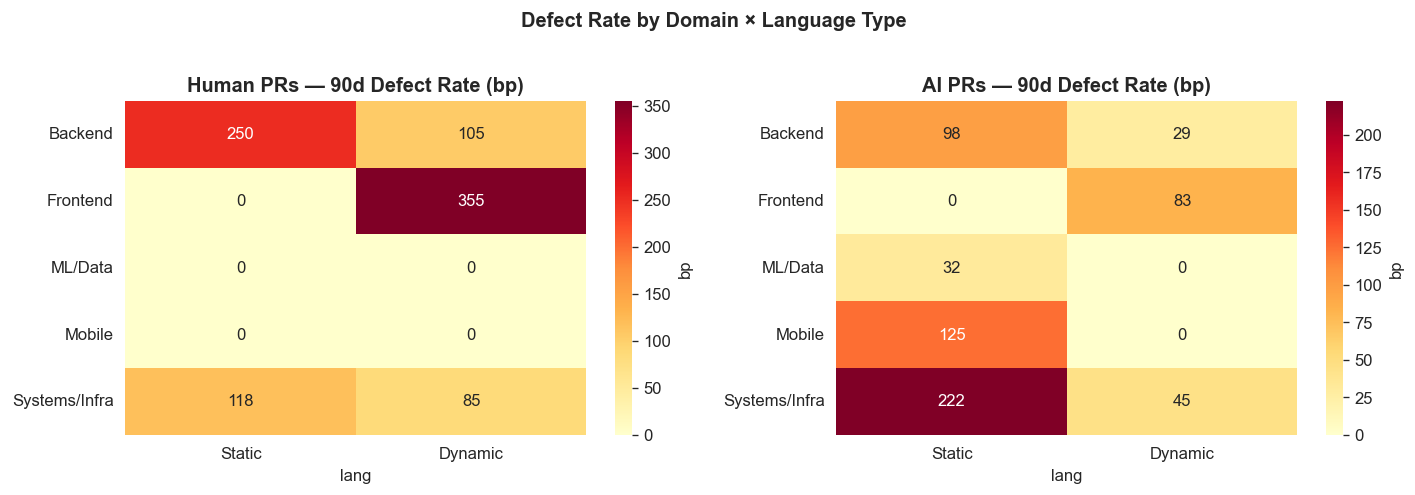

In [13]:
# ── Defect rates by Language Type × Author × Domain ──
DOMAIN_LABELS = {0: "Backend", 1: "Frontend", 2: "ML/Data", 3: "Mobile", 4: "Systems/Infra"}

print("─── 90d Defect Rate by Language Type × Author × Domain ───\n")
rows = []
for dom_code, dom_name in DOMAIN_LABELS.items():
    for lang_code, lang_name in [(1, "Static"), (0, "Dynamic")]:
        for ai_code, ai_name in [(0, "Human"), (1, "AI")]:
            mask = (dfm["domain_type_group"] == dom_code) & (dfm["is_static"] == lang_code) & (dfm["ai_pr"] == ai_code)
            sub = dfm[mask]
            n = len(sub)
            d = int(sub["has_defect_90d"].sum()) if n > 0 else 0
            rate = (d / n * 10_000) if n > 0 else 0
            rows.append({"domain": dom_name, "lang": lang_name, "author": ai_name, "n": n, "defects": d, "rate_bps": rate})

domain_df = pd.DataFrame(rows)
# Only show cells with n >= 20
domain_show = domain_df[domain_df["n"] >= 20]
print(domain_show.to_string(index=False, float_format=lambda x: f"{x:.1f}"))

# ── Heatmap: AI defect rate by domain × language type ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, author in zip(axes, ["Human", "AI"]):
    sub = domain_df[domain_df["author"] == author]
    pivot = sub.pivot(index="domain", columns="lang", values="rate_bps")
    pivot = pivot.reindex(columns=["Static", "Dynamic"])
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
                cbar_kws={"label": "bp"}, vmin=0)
    ax.set_title(f"{author} PRs — 90d Defect Rate (bp)", fontweight="bold")
    ax.set_ylabel("")

fig.suptitle("Defect Rate by Domain × Language Type", fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 14. Power Analysis for Interaction Term

Can we detect a meaningful difference in the AI effect between Static and Dynamic languages given our sample size?

In [14]:
# ── Power analysis for detecting interaction effect ──
# The interaction test asks: does the AI effect (OR) differ between Static and Dynamic?
# We treat this as comparing two proportions (AI defect rate) between language types.

# Observed rates
static_human  = dfm[(dfm["is_static"]==1) & (dfm["ai_pr"]==0)]["has_defect_90d"].mean()
static_ai     = dfm[(dfm["is_static"]==1) & (dfm["ai_pr"]==1)]["has_defect_90d"].mean()
dynamic_human = dfm[(dfm["is_static"]==0) & (dfm["ai_pr"]==0)]["has_defect_90d"].mean()
dynamic_ai    = dfm[(dfm["is_static"]==0) & (dfm["ai_pr"]==1)]["has_defect_90d"].mean()

n_static  = len(dfm[dfm["is_static"]==1])
n_dynamic = len(dfm[dfm["is_static"]==0])

# AI advantage (risk difference) in each group
rd_static  = static_human - static_ai
rd_dynamic = dynamic_human - dynamic_ai

print("─── Observed AI Advantage (Risk Difference) ───\n")
print(f"  Static:  Human {static_human*10_000:.1f} bp − AI {static_ai*10_000:.1f} bp = Δ {rd_static*10_000:.1f} bp")
print(f"  Dynamic: Human {dynamic_human*10_000:.1f} bp − AI {dynamic_ai*10_000:.1f} bp = Δ {rd_dynamic*10_000:.1f} bp")
print(f"  Interaction (difference of differences): {(rd_dynamic - rd_static)*10_000:.1f} bp")

# Cohen's h for the observed interaction
from statsmodels.stats.proportion import proportion_effectsize
h_observed = abs(proportion_effectsize(rd_static, rd_dynamic)) if rd_static != rd_dynamic else 0

# Power analysis
power_analysis = NormalIndPower()

# What effect size can we detect at 80% power?
min_h_80 = power_analysis.solve_power(
    effect_size=None, nobs1=n_static, ratio=n_dynamic/n_static,
    alpha=0.05, power=0.80
)

# What is our actual power for the observed effect?
if h_observed > 0:
    actual_power = power_analysis.solve_power(
        effect_size=h_observed, nobs1=n_static, ratio=n_dynamic/n_static,
        alpha=0.05, power=None
    )
else:
    actual_power = 0.05  # at null

print(f"\n─── Power Analysis ───\n")
print(f"  n_static = {n_static:,}, n_dynamic = {n_dynamic:,}")
print(f"  Minimum detectable Cohen's h at 80% power: {min_h_80:.4f}")
print(f"  Observed Cohen's h for interaction: {h_observed:.4f}")
print(f"  Achieved power for observed effect: {actual_power:.1%}")
print(f"  → {'ADEQUATELY powered' if actual_power >= 0.80 else 'UNDERPOWERED'} to detect this interaction size")

─── Observed AI Advantage (Risk Difference) ───

  Static:  Human 182.7 bp − AI 137.9 bp = Δ 44.8 bp
  Dynamic: Human 279.5 bp − AI 70.4 bp = Δ 209.1 bp
  Interaction (difference of differences): 164.3 bp

─── Power Analysis ───

  n_static = 10,571, n_dynamic = 4,307
  Minimum detectable Cohen's h at 80% power: 0.0506
  Observed Cohen's h for interaction: 0.1562
  Achieved power for observed effect: 100.0%
  → ADEQUATELY powered to detect this interaction size
